### **Image processing: Exploring geometric, logical and morphological operations in images + Color spaces (Part I)**  

**This lab is composed of two parts.**

**You must submit a single lab report covering both Part I and Part II.**

**Part II will be sent before the start of next week's session.**

**The lab report is due by the end of the second lab session.**

In this lab, you will explore essential image processing techniques that transform and enhance images, allowing you to extract meaningful insights. These foundational operations serve as building blocks for more advanced computer vision applications.  

### **What you will learn in this Lab:**  
- You will understand the principles behind **geometric transformations and logical operations** in image processing.  
- You will apply **geometric transformations** such as **resizing, rotation, translation, and perspective modification** to adjust image properties.  
- You will perform **bitwise logical operations** to manipulate and combine images.  
- Learn about **morphological operations** to enhance and extract structural information from images.  
- Explore **color spaces** and how to convert between different color models for advanced image processing.  

---  




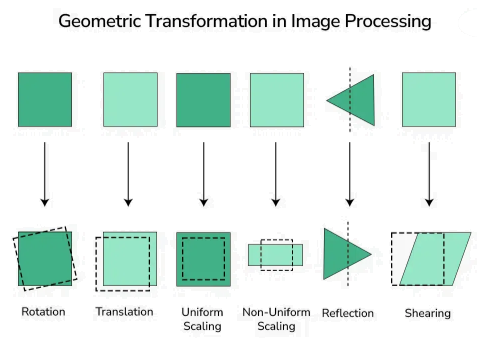
-----

### Understanding the libraries used
Before starting the lab, provide a brief definition of the following libraries and their role in image processing:

- **OpenCV**: Open Source Computer Vision Library, primarily used for image and video processing tasks such as geometric transformations, filtering, and morphological operations.
  
- **NumPy**: A fundamental package for numerical computing in Python, providing support for arrays, matrices, and mathematical functions used in image processing.
  
- **Matplotlib**: A plotting library for Python that enables visualization of images, histograms, and transformations applied to images.

If not installed, you can install them using:

`pip install opencv-python numpy matplotlib`

In [1]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

# Manipulation 1: Geometric Transformations  

You will explore **geometric transformations** and their role in image processing, including:  

- **Resizing (Scaling)** – Adjusting the image dimensions while preserving or modifying aspect ratios.  
- **Translation** – Moving an image to a different position without altering its content.  
- **Rotation** – Changing the orientation of an image around a fixed point.  
- **Shearing** – Slanting the image along an axis, distorting its shape.  
- **Perspective Transformation** – Adjusting the image’s perspective to simulate different viewpoints.  



### Why are these transformations important?  

They are widely used in various computer vision tasks, such as:  

- **Image alignment** – Aligning images for analysis and comparison.  
- **Data augmentation** – Creating variations of images for training machine learning models.  
- **Perspective correction** – Fixing distortions in images for better representation and analysis.  

### **Theoretical research:** Provide bellow a description of the following key concepts (using your own words):


* **Geometrical transformations** : Geometrical transformations are operations that modify the position, size, orientation, or shape of an image using mathematical rules (such as scaling, rotation, and translation) without changing the actual pixel intensity values.

* **Logical operations** : Logical operations are pixel-by-pixel operations based on Boolean logic (AND, OR, NOT, XOR) used mainly on binary images to combine, compare, or invert image regions.

* **Morphological operations** : Morphological operations are image processing techniques that modify the shape of objects in binary or grayscale images using a structuring element. Common operations include erosion and dilation, which are used to remove noise, fill gaps, or extract shapes.


## Task 1: Image scaling  

#### **T 1.1: Resizing algorithms**  

Explore and compare different image resizing methods. For each method, provide a description of how it works:  

- **Nearest neighbor** (Simplest method, but may cause pixelation) : Assigns each pixel in the resized image the value of the closest pixel from the original image. Very fast, but can look blocky when enlarging.

- **Bilinear interpolation** (Better quality, considers neighboring pixels) : Computes each new pixel using a weighted average of the 4 nearest original pixels, giving smoother results but slightly blurred edges.

- **Bicubic interpolation** (Higher quality, but more computationally expensive) : Estimates each new pixel from a 4×4 neighborhood (16 pixels) using cubic interpolation, producing smoother and sharper results but requiring more computation.


---

**Manual implementation of a resizing algorithm:** Write a function that implements the nearest neighbor resizing algorithm manually, without using any built-in functions for resizing. The new size can be provided as absolute values and also as positive/negative ratios.

- Load the `cameraman.png` image. 
- Resize the `cameraman.png` image both up and down using the nearest neighbor method you have implemented. Perform at leat 6 differents resizings.
- Display the original image along with its size.  
- Display the resized images with their new sizes.  

**Hint:** You can achieve this by iterating over the pixel values and mapping them to a new zero matrix (black image) with the desired size based on the chosen interpolation method. It is important to warn the user if the new size of the image does not preserve the aspect ratio (but the resize has to be performed anyway).

**Perform the same work for another resizing method: Bilinear interpolation or Bicubic interpolation.**

**Analyse the obtained images.**


Original size: (256, 256)


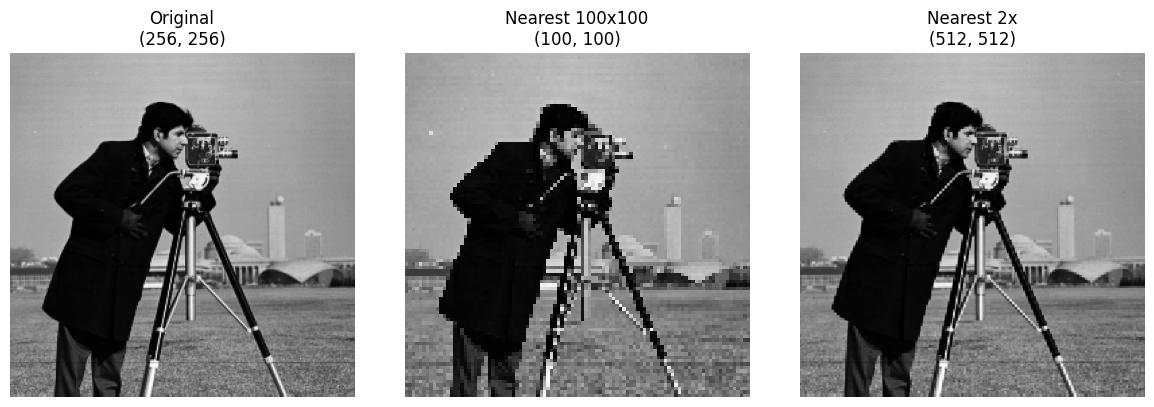

In [21]:
# Your code here.
import numpy as np
import matplotlib.pyplot as plt
import os

def resize_nearest(img, new_size=None, ratio=None):

    old_h, old_w = img.shape

    # --------- Determine new size ----------
    if new_size is not None:
        new_h, new_w = new_size
    elif ratio is not None:
        if ratio > 0:
            scale = ratio
        else:
            scale = 1 / abs(ratio)   
        new_h = int(old_h * scale)
        new_w = int(old_w * scale)
    else:
        raise ValueError("Provide new_size or ratio")

    # --------- Aspect ratio warning ----------
    old_ratio = old_w / old_h
    new_ratio = new_w / new_h
    if abs(old_ratio - new_ratio) > 0.01:
        print("Aspect ratio changed!")

    # --------- Create new empty image ----------
    resized = np.zeros((new_h, new_w), dtype=np.uint8)

    scale_y = old_h / new_h
    scale_x = old_w / new_w

    # --------- Nearest Neighbor Mapping ----------
    for i in range(new_h):
        for j in range(new_w):

            old_i = int(round(i * scale_y))
            old_j = int(round(j * scale_x))

            old_i = min(old_i, old_h - 1)
            old_j = min(old_j, old_w - 1)

            resized[i, j] = img[old_i, old_j]

    return resized


# -------------------------------------------------
# LOAD IMAGE
# -------------------------------------------------
img = plt.imread("Images/cameraman.png")
img = (img * 255).astype(np.uint8) if img.max() <= 1 else img.astype(np.uint8)
print("Original size:", img.shape)

res_small = resize_nearest(img, new_size=(100, 100))  
res_large = resize_nearest(img, ratio=2)              


# -------------------------------------------------
# DISPLAY ORIGINAL + SMALL + BIG
# -------------------------------------------------
plt.figure(figsize=(12, 4))

# Original
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(f"Original\n{img.shape}")
plt.axis("off")

# Small (100x100)
plt.subplot(1, 3, 2)
plt.imshow(res_small, cmap='gray')
plt.title(f"Nearest 100x100\n{res_small.shape}")
plt.axis("off")

# Large (2x)
plt.subplot(1, 3, 3)
plt.imshow(res_large, cmap='gray')
plt.title(f"Nearest 2x\n{res_large.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()



#### **Analysis of the Resized Images (Nearest Neighbor)**

From the obtained results, we observe the following:

When reducing the image size to 100×100, the image becomes significantly smaller and some fine details disappear. The overall structure of the image remains recognizable, but textures and small elements are less clear. This happens because nearest neighbor skips pixels during downscaling, which causes loss of information.

When enlarging the image to 2× (512×512), pixelation becomes clearly visible. The edges appear jagged and blocky because the method simply copies the closest pixel value without smoothing or averaging. As a result, large square-like pixels can be observed in the enlarged image.

In both cases, the aspect ratio is preserved, so the image does not appear geometrically distorted. However, the visual quality changes depending on whether the image is reduced or enlarged.

>**Conclusion** :
> the nearest neighbor method is simple and fast, but it produces blocky results when enlarging and loses detail when reducing size.


#### **Bilinear interpolation**

We will now apply the same resizing operations using bilinear interpolation and compare the results with the nearest neighbor method. 

Unlike nearest neighbor, bilinear interpolation computes each new pixel value using a weighted average of the four closest neighboring pixels. This produces smoother transitions between pixels and reduces the blocky appearance observed in nearest neighbor resizing.

By performing both downscaling (100×100) and upscaling (2×), we can evaluate how bilinear interpolation affects image quality in terms of smoothness, sharpness, and detail preservation.


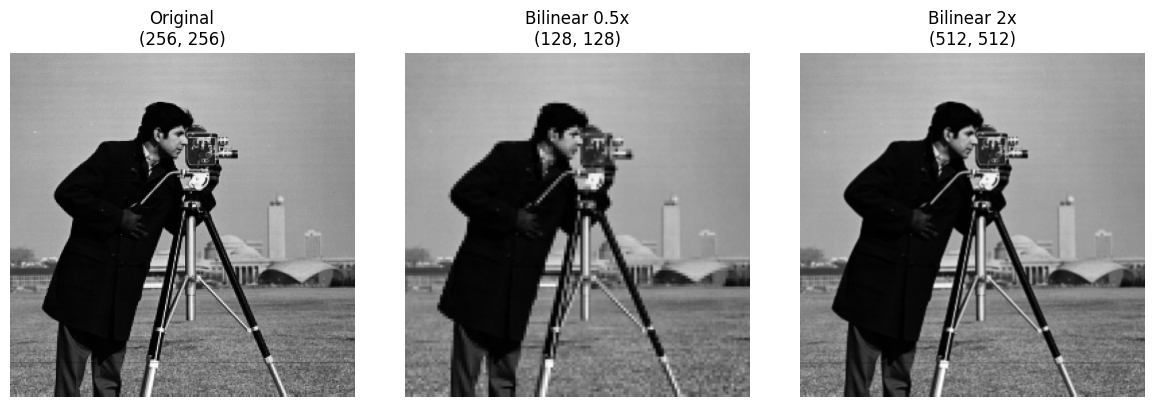

In [20]:
def resize_bilinear(img, new_size=None, ratio=None):

    old_h, old_w = img.shape

    # --------- Determine new size ----------
    if new_size is not None:
        new_h, new_w = new_size
    elif ratio is not None:
        if ratio > 0:
            scale = ratio
        else:
            scale = 1 / abs(ratio)
        new_h = int(old_h * scale)
        new_w = int(old_w * scale)
    else:
        raise ValueError("Provide new_size or ratio")

    # --------- Aspect ratio warning ----------
    old_ratio = old_w / old_h
    new_ratio = new_w / new_h
    if abs(old_ratio - new_ratio) > 0.01:
        print("Aspect ratio changed!")

    resized = np.zeros((new_h, new_w), dtype=np.uint8)

    scale_y = (old_h - 1) / (new_h - 1) if new_h > 1 else 0
    scale_x = (old_w - 1) / (new_w - 1) if new_w > 1 else 0

    for i in range(new_h):
        for j in range(new_w):

            y = i * scale_y
            x = j * scale_x

            y0 = int(np.floor(y))
            x0 = int(np.floor(x))

            y1 = min(y0 + 1, old_h - 1)
            x1 = min(x0 + 1, old_w - 1)

            dy = y - y0
            dx = x - x0

            # 4 surrounding pixels
            Q11 = img[y0, x0]
            Q21 = img[y0, x1]
            Q12 = img[y1, x0]
            Q22 = img[y1, x1]

            # Bilinear formula
            value = (
                Q11 * (1 - dx) * (1 - dy) +
                Q21 * dx * (1 - dy) +
                Q12 * (1 - dx) * dy +
                Q22 * dx * dy
            )

            resized[i, j] = int(value)

    return resized


# ----- Generate only 2 bilinear resizes -----
bil_small = resize_bilinear(img, ratio=0.5)   
bil_large = resize_bilinear(img, ratio=2)     

# ----- Plot -----
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(f"Original\n{img.shape}")
plt.axis("off")

# Smaller
plt.subplot(1, 3, 2)
plt.imshow(bil_small, cmap='gray')
plt.title(f"Bilinear 0.5x\n{bil_small.shape}")
plt.axis("off")

# Larger
plt.subplot(1, 3, 3)
plt.imshow(bil_large, cmap='gray')
plt.title(f"Bilinear 2x\n{bil_large.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()




#### **Analysis of the Resized Images (Bilinear Interpolation)**

From the obtained results, we observe the following:

When reducing the image size to 0.5× (128×128), the image becomes smaller while maintaining smooth transitions between pixel intensities. Although some fine details are reduced due to lower resolution, the image appears smoother compared to nearest neighbor interpolation.

When enlarging the image to 2× (512×512), the result looks significantly smoother than the nearest neighbor method. The edges are less jagged and the blocky effect is reduced. This is because bilinear interpolation calculates each new pixel using a weighted average of the four surrounding pixels, which creates gradual intensity transitions.

In both cases, the aspect ratio is preserved, so no geometric distortion is observed. The overall structure of the image remains natural and visually pleasing.

> **Conclusion** :
> bilinear interpolation provides better visual quality than nearest neighbor. It reduces pixelation when enlarging and produces smoother results, although it may introduce slight blurring due to the averaging process.


#### **T 1.2: Image resizing using built-in functions of OpenCV**  

The `resize()` function in OpenCV allows adjusting the size of an image in different ways:  

- Scaling using axis-specific factors:  
   - `fx`: Scale factor along the **horizontal axis**.  
   - `fy`: Scale factor along the **vertical axis**.  

- Interpolation parameter (`interpolation`)  
   - Determines how pixel values are calculated when resizing.  
   - Common interpolation methods:  
     - `cv2.INTER_NEAREST`
     - `cv2.INTER_LINEAR`
     - `cv2.INTER_CUBIC`  

---

Before applying the `resize()` function, youl will first create a simple grayscale test image using `NumPy` and `Matplotlib`. The image will be **6×6 pixels** and structured as follows:  

- The background is black *(pixel value = 0)*.  
- A white square *(pixel value = 255)* fills the inner **4×4** region, starting from **row 1 and column 1**.  
- A smaller black square *(pixel value = 0)* is embedded inside the white square, occupying the **central 2×2** region.  

Once the image (`imgtest`) is created, it should be displayed before applying any resizing operations.  

After generating the test image, the next step is to apply the `resize()` function to modify its dimensions. This involves adjusting the scale factors along the horizontal (`fx`) and vertical (`fy`) axes and experimenting with different interpolation methods.  

To do this, follow these steps:  
1. Use `resize()` to scale `imgtest` by modifying the `fx` and `fy` values.  
2. Apply different interpolation methods (`INTER_NEAREST`, `INTER_LINEAR`, `INTER_CUBIC`) and observe their effects.  
3. Display both the original and resized versions of `imgtest` and analyze the differences.  


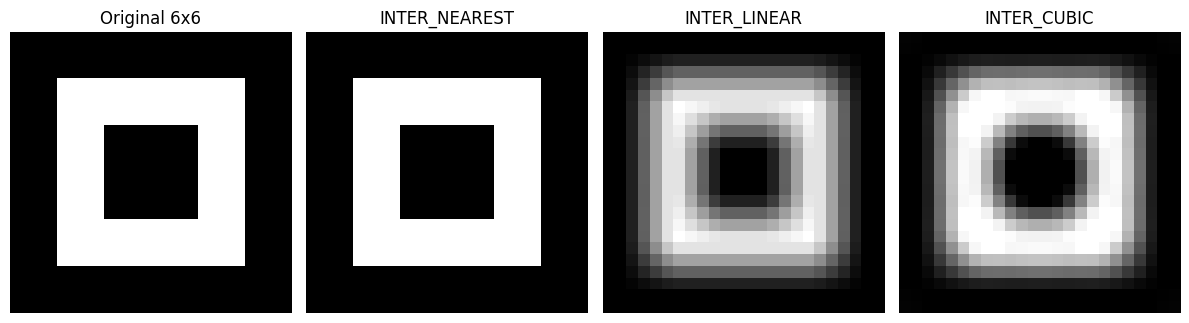

In [22]:
# Create and display the 6×6 grayscale test image, then follow the steps described above.
import numpy as np
import matplotlib.pyplot as plt
import cv2

# --------------------------------------------------
# 1) Create 6x6 test image
# --------------------------------------------------
imgtest = np.zeros((6, 6), dtype=np.uint8)

# Inner 4x4 white square
imgtest[1:5, 1:5] = 255

# Central 2x2 black square
imgtest[2:4, 2:4] = 0

# --------------------------------------------------
# 2) Resize using OpenCV with different interpolations
# --------------------------------------------------
fx = 4
fy = 4

resize_nearest = cv2.resize(imgtest, None, fx=fx, fy=fy, interpolation=cv2.INTER_NEAREST)
resize_linear  = cv2.resize(imgtest, None, fx=fx, fy=fy, interpolation=cv2.INTER_LINEAR)
resize_cubic   = cv2.resize(imgtest, None, fx=fx, fy=fy, interpolation=cv2.INTER_CUBIC)

# --------------------------------------------------
# 3) Display original + resized images
# --------------------------------------------------
plt.figure(figsize=(12, 4))

# Original
plt.subplot(1, 4, 1)
plt.imshow(imgtest, cmap='gray', interpolation='nearest')
plt.title("Original 6x6")
plt.axis("off")

# Nearest
plt.subplot(1, 4, 2)
plt.imshow(resize_nearest, cmap='gray')
plt.title("INTER_NEAREST")
plt.axis("off")

# Linear
plt.subplot(1, 4, 3)
plt.imshow(resize_linear, cmap='gray')
plt.title("INTER_LINEAR")
plt.axis("off")

# Cubic
plt.subplot(1, 4, 4)
plt.imshow(resize_cubic, cmap='gray')
plt.title("INTER_CUBIC")
plt.axis("off")

plt.tight_layout()
plt.show()


After experimenting with the test image, you will now apply the `resize()` function to a **real-world image**, `cameraman.png`. This will allow you to observe how resizing affects a more complex image compared to the simple structured pattern of `imgtest`.  

To analyze the effects of resizing, follow these steps:  

1. Resize `cameraman.png` by adjusting `fx` and `fy` values to scale the image both up and down.  
2. Apply a scaling factor between `0` and `1` to shrink the image while maintaining aspect ratio.  
3. Resize the image by specifying exact dimensions (`rows = 250`, `cols = 400`) instead of using scale factors.  
4. Compare the resized outputs with those from `imgtest` and discuss how interpolation affects a natural image differently from a synthetic one.  


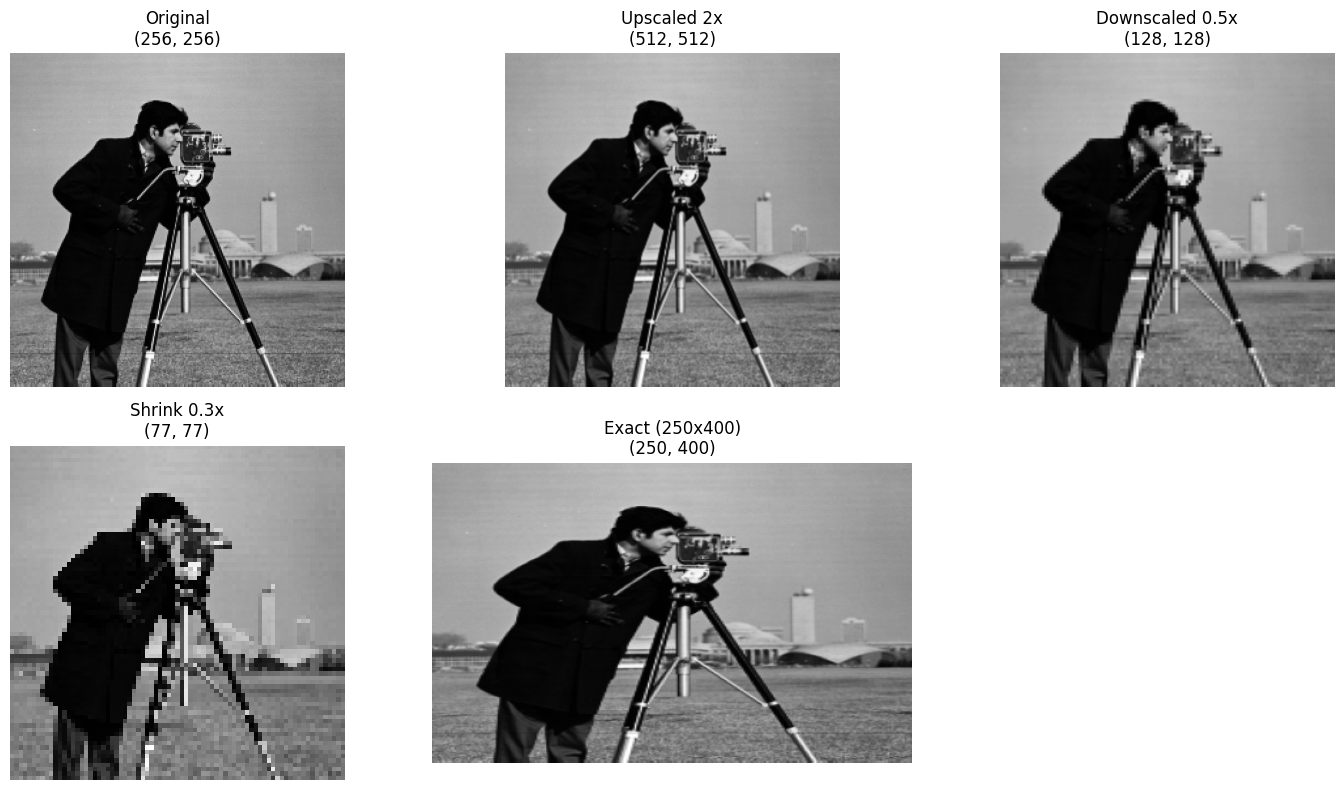

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("Images/cameraman.png", cv2.IMREAD_GRAYSCALE)


img_up = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
img_down = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
img_shrink = cv2.resize(img, None, fx=0.3, fy=0.3, interpolation=cv2.INTER_LINEAR)
img_exact = cv2.resize(img, (400, 250), interpolation=cv2.INTER_LINEAR)


plt.figure(figsize=(15,8))

images = [img, img_up, img_down, img_shrink, img_exact]
titles = [
    f"Original\n{img.shape}",
    f"Upscaled 2x\n{img_up.shape}",
    f"Downscaled 0.5x\n{img_down.shape}",
    f"Shrink 0.3x\n{img_shrink.shape}",
    f"Exact (250x400)\n{img_exact.shape}"
]

for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


### Questions:
After applying the `resize()` function to both `imgtest` and `cameraman.png`, analyze the results by answering the following questions:  

1. How does resizing a structured test image (`imgtest`) compare to resizing a real-world image (`cameraman.png`)?  
2. What differences do you observe when using different interpolation methods?  
3. How does resizing with a scaling factor (`fx`, `fy`) differ from specifying exact dimensions (`rows`, `cols`)?  
4. Which method produces the best visual quality for **upscaling** and which one for **downscaling**? Explain why.
5. Analyse this transformation considering the aspect ratio.
6. Analyze and compare the obtained resized images with those obtained using the function you implementd in **T1.1**.

---

## **Analysis and Answers**

### 1. How does resizing a structured test image (`imgtest`) compare to resizing a real-world image (`cameraman.png`)?

Resizing the structured test image (`imgtest`) produces very clear and noticeable interpolation effects because the image contains sharp edges and uniform regions (black and white squares). Any smoothing or pixelation becomes immediately visible.

In contrast, resizing the real-world image (`cameraman.png`) produces more gradual visual changes. Since natural images contain textures, gradients, and complex details, interpolation effects are less abrupt but still affect sharpness and detail preservation.

---

### 2. What differences do you observe when using different interpolation methods?

- **INTER_NEAREST**: Produces sharp edges but causes blocky and pixelated results, especially during upscaling.
- **INTER_LINEAR**: Produces smoother transitions between pixels and reduces blockiness.
- **INTER_CUBIC**: Produces even smoother and higher-quality results, especially when enlarging, but may introduce slight blurring.

The differences are more obvious in the synthetic test image than in the real-world image.

---

### 3. How does resizing with scaling factors (`fx`, `fy`) differ from specifying exact dimensions (`rows`, `cols`)?

Using scaling factors (`fx`, `fy`) resizes the image proportionally based on multiplication. It is easier to preserve the aspect ratio when both factors are equal.

Specifying exact dimensions (`rows`, `cols`) directly sets the new size. If the aspect ratio is not preserved, the image may become stretched or compressed.

---

### 4. Which method produces the best visual quality for upscaling and which one for downscaling?

- For **upscaling**, `INTER_CUBIC` generally produces the best visual quality because it provides smoother and more natural results.
- For **downscaling**, `INTER_LINEAR` is usually sufficient and provides good quality with lower computational cost.

`INTER_NEAREST` is not recommended when visual quality is important.

---

### 5. Analyze this transformation considering the aspect ratio.

If the aspect ratio is preserved (same scaling factor for both axes), the image maintains its geometric proportions. If different values are used for width and height, the image becomes distorted, and objects appear stretched or compressed.

---

### 6. Compare the OpenCV resize results with your manual implementation (T1.1).

The OpenCV results are smoother and more visually consistent compared to the manual nearest neighbor implementation. The manual method produces similar results to `INTER_NEAREST`, including pixelation during enlargement. OpenCV interpolation methods (linear and cubic) provide improved visual quality and reduced artifacts.



## Task 2: Image translation  

Geometric transformations involve mathematical operations that modify the coordinates of the image's pixels. These transformations are typically represented using transformation matrices that define how each point in the image is repositioned.  

#### **Understanding translation**  

Translation refers to shifting an image by a specified number of pixels along the **x-axis** and **y-axis**. This operation moves every pixel in the image without altering its shape, size or orientation.  

Mathematically, translation is represented as follows:  

$$
\begin{bmatrix}
x' \\ y'
\end{bmatrix}
=
\begin{bmatrix}
x + \Delta x \\ y + \Delta y
\end{bmatrix}
$$  

where:  

- \( $x'$ \) and \( $y'$ \) are the new coordinates after translation.  
- \( $x$ \) and \( $y$ \) are the original coordinates of the pixel.  
- \( $\Delta x$ \) and \( $\Delta y$ \) are the translation offsets along the horizontal and vertical axes, respectively.  

Translation is often used for **image alignment, object tracking, and perspective adjustments** in computer vision tasks.  


-------
**Exampel of translation**

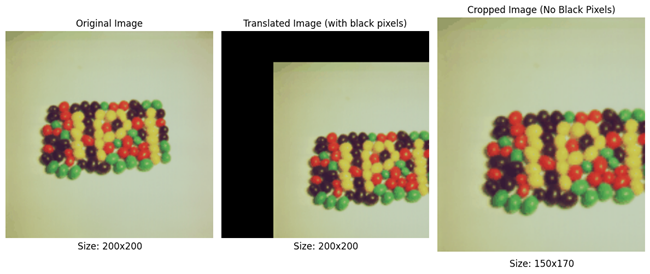


In this task, you will apply **image translation** using OpenCV's `warpAffine()` function to shift an image in different directions.  

### **Instructions:**  
1. Select an image from the given `images` folder to perform the translation.  
2. Translate the image by shifting:  
   - 100 pixels horizontally (along the x-axis).  
   - 200 pixels vertically (along the y-axis).  
   - Both axes simultaneously (100 pixels right and 200 pixels down).  
3. Remove the black pixels that appear after translation.  
4. Use the function `warpAffine()` from the `cv2` module to apply the transformation.  
5. Analyze the results by observing how translation affects the image and discussing potential use cases.  


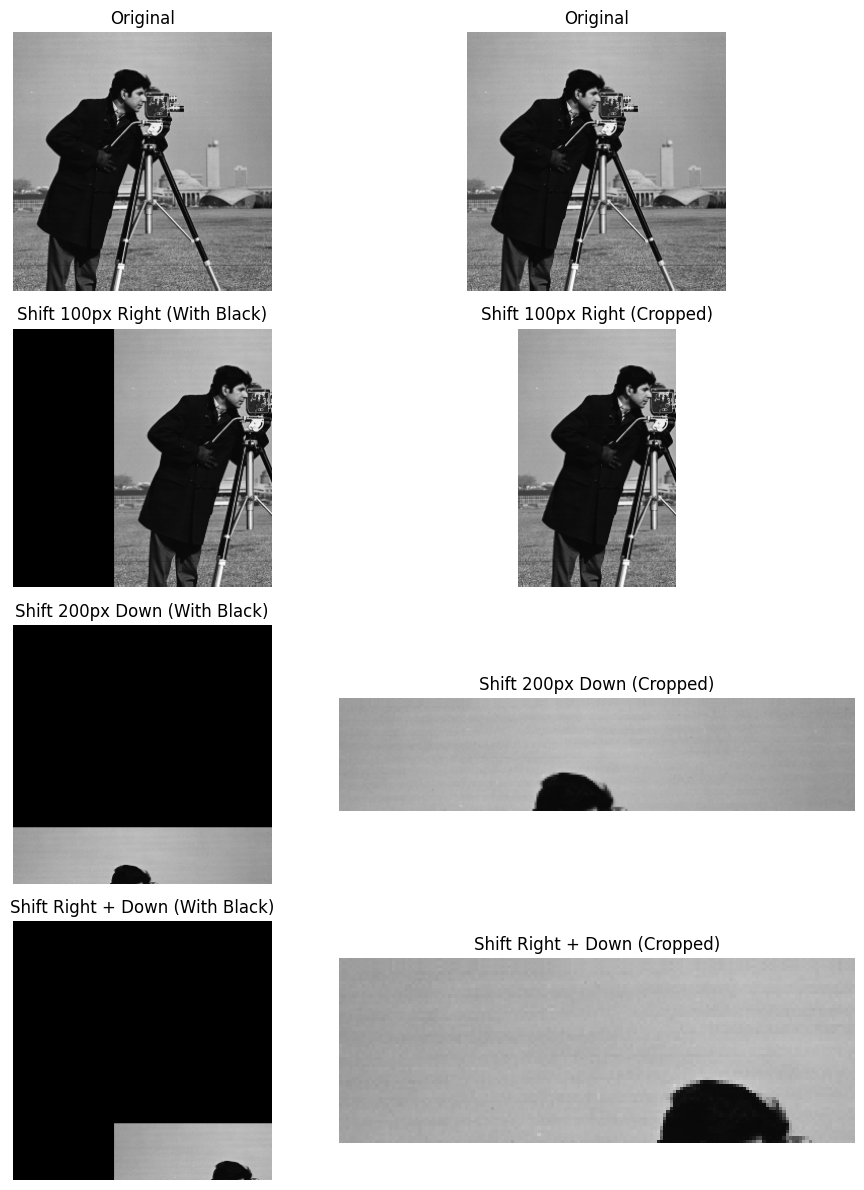

In [ ]:
# Perform image translation as described above.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Images/cameraman.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# 1) 100 pixels horizontally (right)
M_x = np.float32([[1, 0, 100],
                  [0, 1, 0]])

# 2) 200 pixels vertically (down)
M_y = np.float32([[1, 0, 0],
                  [0, 1, 200]])

# 3) Both directions (100 right, 200 down)
M_xy = np.float32([[1, 0, 100],
                   [0, 1, 200]])

trans_x  = cv2.warpAffine(img, M_x,  (w, h))
trans_y  = cv2.warpAffine(img, M_y,  (w, h))
trans_xy = cv2.warpAffine(img, M_xy, (w, h))


def crop_black(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    coords = cv2.findNonZero(gray)
    x, y, w, h = cv2.boundingRect(coords)
    return image[y:y+h, x:x+w]

crop_x  = crop_black(trans_x)
crop_y  = crop_black(trans_y)
crop_xy = crop_black(trans_xy)

plt.figure(figsize=(10,12))

images = [
    img, img,                    # Original (just duplicated for layout symmetry)
    trans_x, crop_x,             # Right shift
    trans_y, crop_y,             # Down shift
    trans_xy, crop_xy            # Right + Down shift
]

titles = [
    "Original",
    "Original",

    "Shift 100px Right (With Black)",
    "Shift 100px Right (Cropped)",

    "Shift 200px Down (With Black)",
    "Shift 200px Down (Cropped)",

    "Shift Right + Down (With Black)",
    "Shift Right + Down (Cropped)"
]

for i in range(len(images)):
    plt.subplot(4, 2, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


### Questions:
1. How does translating the image affect its appearance?  
2. What happens to the pixels that are shifted beyond the image boundaries?  
3. Why do black pixels appear after translation, and how can they be removed effectively?  
4. Compare translating along a **single axis ($x$ or $y$)** vs. translating along **both axes simultaneously**—what differences do you notice?


## Analysis and Answers – Image Translation

### 1. How does translating the image affect its appearance?

Translating the image shifts all pixels in a specific direction (horizontal, vertical, or both) without changing the image’s shape, size, or orientation. The content remains the same, but its position inside the frame changes.

---

### 2. What happens to the pixels that are shifted beyond the image boundaries?

Pixels that move beyond the image boundaries are lost because they fall outside the defined image frame. They are not wrapped around or preserved unless a special border mode is specified.

---

### 3. Why do black pixels appear after translation, and how can they be removed effectively?

Black pixels appear because when the image is shifted, empty areas are created where no pixel data exists. OpenCV fills these empty regions with zeros (black by default).

They can be removed effectively by:
- Cropping the image to remove empty borders.
- Using different border modes (e.g., `cv2.BORDER_REPLICATE`, `cv2.BORDER_REFLECT`).
- Adjusting the output size to avoid unnecessary padding.

---

### 4. Compare translating along a single axis (x or y) vs. translating along both axes simultaneously.

When translating along a single axis:
- The image shifts either horizontally or vertically.
- Black regions appear only on one side.

When translating along both axes:
- The image shifts diagonally.
- Black regions appear along two sides (corner areas).
- More of the original image may be pushed outside the visible frame.

Overall, translating along both axes produces a more noticeable displacement compared to shifting along a single direction.



#### **Challenge 1: Translating an Object**  

In this challenge, you will apply translation to animate the movement of an object inside an image.  

**Use `Circle.png` as the input image**.


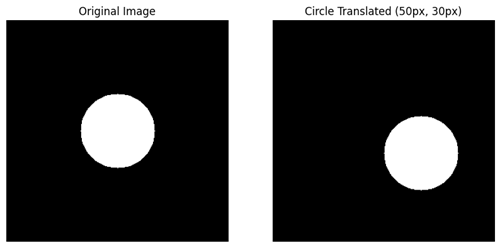

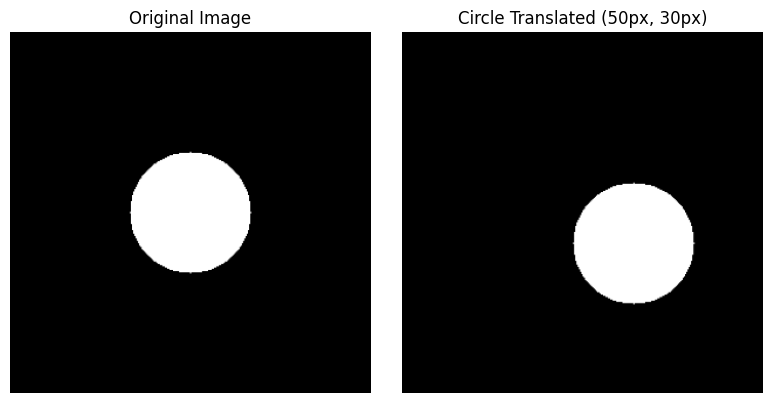

In [ ]:
# Challenge 1: Apply static translation to the image.
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("Images/Circle.png", cv2.IMREAD_GRAYSCALE)
h, w = img.shape
dx = 50
dy = 30
M = np.float32([[1, 0, dx],
                [0, 1, dy]])
translated = cv2.warpAffine(img, M, (w, h))


plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(translated, cmap='gray')
plt.title("Circle Translated (50px, 30px)")
plt.axis("off")

plt.tight_layout()
plt.show()


#### **Challenge 2: Dynamic Object Translation**  
1. Perform horizontal translation → Shift the white circle continuously to the right. Once it reaches the image boundary, it should reappear from the left side.  
2. Perform vertical translation → Shift the circle downward, ensuring it wraps around and reappears from the top.  
3. Apply sinewave-based horizontal translation → Make the circle follow a sinusoidal path as it moves horizontally.  
4. Generate an animation to visualize the movement over time.  



To create a video file, you first need to initialize a **`VideoWriter`** object.  


- Step 1: Define the codec (video format)

  `fourcc = cv2.VideoWriter_fourcc(*'mp4v')`

- Step 2: Create the video writer

  `video_writer = cv2.VideoWriter('your/saving/path/output_video.mp4', fourcc, 30, (image_width, image_height))`

- Step 3: Write frames (each frame corresponds to one translation step) to the video inside a loop

  `video_writer.write(frame)`

- Step 4: Release the video writer (finalize the video file once the loop ends)

  `video_writer.release()`

In [31]:
import cv2
import numpy as np

img = cv2.imread("Images/Circle.png", cv2.IMREAD_GRAYSCALE)
h, w = img.shape
img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output_video.mp4", fourcc, 30, (w, h))

def warp_wrap(im, dx, dy):
    M = np.float32([[1, 0, dx],
                    [0, 1, dy]])
    return cv2.warpAffine(im, M, (w, h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_WRAP)

N = 120
step = 3

# 1) Horizontal translation (wrap)
for t in range(N):
    dx = (t * step) % w
    dy = 0
    out.write(warp_wrap(img, dx, dy))

# 2) Vertical translation (wrap)
for t in range(N):
    dx = 0
    dy = (t * step) % h
    out.write(warp_wrap(img, dx, dy))

# 3) Sinusoidal path while moving horizontally (wrap)
A = h // 4
for t in range(N):
    dx = (t * step) % w
    dy = int(A * np.sin(2 * np.pi * t / N))
    out.write(warp_wrap(img, dx, dy))

out.release()
print("Saved: output_video.mp4")


Saved: output_video.mp4


## Task 3: Image Rotation

Rotation is a geometric transformation that rotates an image around a fixed point (usually the center). The transformation is represented by the following mathematical formula:  

$$
\begin{bmatrix}
x' \\ y'
\end{bmatrix} =
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x \\ y
\end{bmatrix}
$$  

where:  
- \( $x'$ \), \( $y'$ \) are the **new coordinates** after rotation.  
- \( $x$ \), \( $y$ \) are the **original coordinates** of the pixel.  
- \( $\theta$ \) is the **rotation angle** in degrees.  
---

### **Instructions:**  
1. Choose an image from the `images` folder.
1. Write a program to rotate an image at different angles, such as **45°**, **90°**, and a full **360°** rotation.
2. Use `cv2.getRotationMatrix2D()` to generate the rotation matrix and apply it to the image.  
3. Analyze the results by observing how rotation affects the image, especially at different angles.  


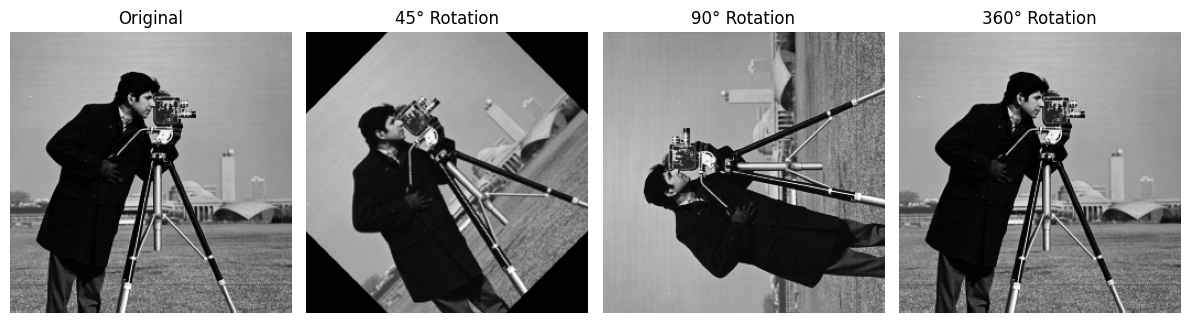

In [32]:
# Apply image rotation using cv2.getRotationMatrix2D() at different angles.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Images/cameraman.png", cv2.IMREAD_GRAYSCALE)
h, w = img.shape

center = (w // 2, h // 2)

angles = [45, 90, 360]
rotated_images = []

for angle in angles:
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h))
    rotated_images.append(rotated)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

for i, angle in enumerate(angles):
    plt.subplot(1,4,i+2)
    plt.imshow(rotated_images[i], cmap='gray')
    plt.title(f"{angle}° Rotation")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Questions:
1. What happens to the image dimensions after rotation? Why do some rotations introduce black borders?  
2. How does OpenCV handle **out-of-frame pixels** during rotation?  


## Analysis and Answers – Image Rotation

### 1. What happens to the image dimensions after rotation? Why do some rotations introduce black borders?

When rotating an image using `cv2.warpAffine()` with the original width and height, the output image keeps the same dimensions. However, rotating the image changes the orientation of the pixels inside that fixed frame.

For angles such as 45°, parts of the image extend beyond the original rectangular boundaries. Since the output size remains unchanged, some areas fall outside the frame and empty regions appear. These empty regions are filled with black pixels by default, which results in visible black borders.

For rotations like 90° or 360°, the image aligns better with the rectangular frame, so fewer or no black borders appear.

---

### 2. How does OpenCV handle out-of-frame pixels during rotation?

During rotation, some pixels move outside the visible image area. OpenCV handles these cases in two ways:

- Pixels that move outside the output frame are discarded (they are lost).
- Newly created empty areas inside the frame are filled according to the selected border mode.

By default, OpenCV uses a constant border value (black pixels). However, different border modes can be specified, such as:
- `cv2.BORDER_CONSTANT`
- `cv2.BORDER_REPLICATE`
- `cv2.BORDER_REFLECT`
- `cv2.BORDER_WRAP`

These options determine how OpenCV fills the regions where no original pixel data exists.

In summary, OpenCV keeps the output size fixed, removes pixels that fall outside the frame, and fills empty areas using the selected border handling method.



#### **Challenge: Custom Rotation Point**  

By default, image rotation occurs around the **center of the image**. In this challenge, you will modify the transformation to **rotate an image around a custom point** instead.  

### **Instructions:**  
1. Use the same image as before or choose a different one from the `images` folder.  
2. Select a custom pivot point (e.g., a corner, an off-center point, or a specific feature in the image).  
3. Use `cv2.getRotationMatrix2D()` to compute the transformation matrix based on the chosen pivot point.  
4. Apply the rotation and display the resulting image.  
5. Analyze the difference between center-based rotation and custom-point rotation.  


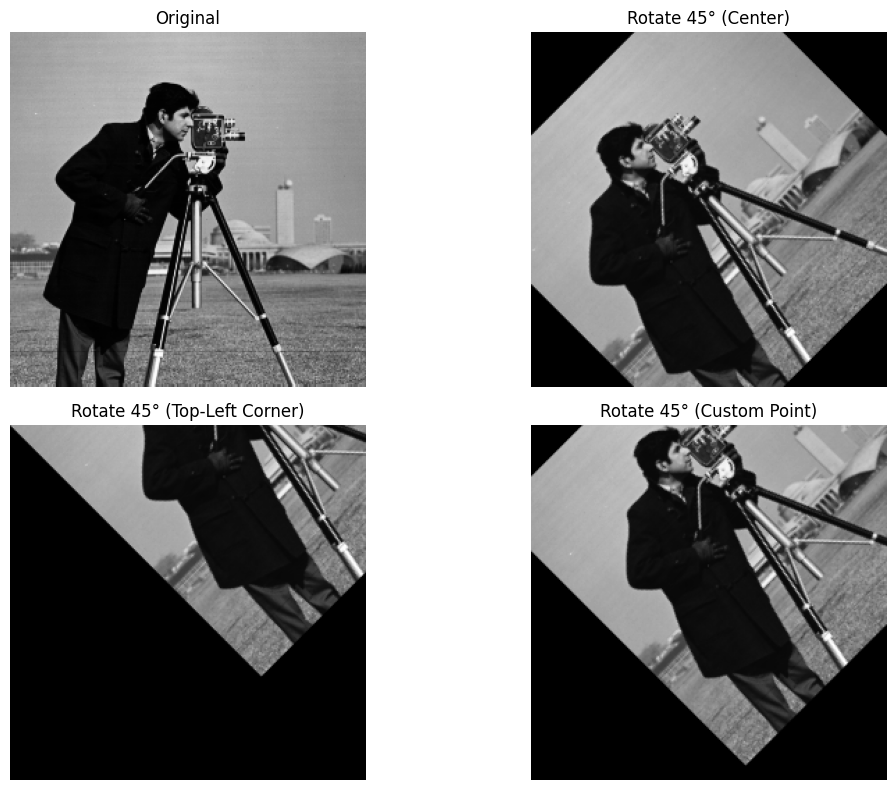

In [33]:
# Challenge: Apply rotation around custom pivot points instead of the center.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Images/cameraman.png", cv2.IMREAD_GRAYSCALE)
h, w = img.shape

angle = 45

center_point = (w//2, h//2)
corner_point = (0, 0)
custom_point = (w//4, h//4)

M_center = cv2.getRotationMatrix2D(center_point, angle, 1.0)
M_corner = cv2.getRotationMatrix2D(corner_point, angle, 1.0)
M_custom = cv2.getRotationMatrix2D(custom_point, angle, 1.0)

rot_center = cv2.warpAffine(img, M_center, (w, h))
rot_corner = cv2.warpAffine(img, M_corner, (w, h))
rot_custom = cv2.warpAffine(img, M_custom, (w, h))

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(rot_center, cmap='gray')
plt.title("Rotate 45° (Center)")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(rot_corner, cmap='gray')
plt.title("Rotate 45° (Top-Left Corner)")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(rot_custom, cmap='gray')
plt.title("Rotate 45° (Custom Point)")
plt.axis("off")

plt.tight_layout()
plt.show()


### **Analysis – Custom Rotation Point**

When rotating the image around the **center**, the image appears to spin in place. The main object remains roughly in the middle of the frame, and the rotation looks balanced. Black borders appear because the rotated image no longer fully fits inside the original rectangular frame.

When rotating around the **top-left corner**, the image rotates around that corner as a fixed pivot. As a result, most of the image moves away from its original position, and large black areas appear. The rotation looks like the image is swinging around the corner.

When rotating around a **custom off-center point**, the image rotates around that selected pivot. The displacement depends on how far the pivot is from the center. The object shifts position differently compared to center rotation, and black regions appear unevenly.

Overall, the pivot point significantly affects how the image moves during rotation. Center-based rotation preserves symmetry, while corner or custom-point rotation causes noticeable translation effects in addition to rotation.


## Task 4: Affine Transformation  

Affine transformations are a class of geometric transformations that preserve **collinearity** (straight lines remain straight) and **ratios of distances** between points. They include operations such as **scaling, rotation, shearing, and translation**.  


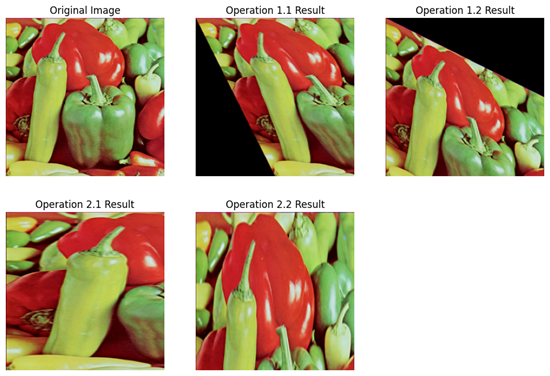

### Analysis of the Transformation:
1. Analyze the given output and determine what type of **transformation** has been applied to the `pepper.png` image.  
2. Explain the effects of the transformation and how it affects the image structure.   

### **Analysis of the Affine Transformation**

From the given results, different affine transformations have been applied to the `pepper.png` image.

Some outputs show **rotation**, where the image is turned around a pivot point while preserving straight lines. Black triangular regions appear because parts of the rotated image fall outside the original frame.

Other outputs show **scaling**, where the image is resized either larger or smaller. The proportions of objects remain consistent, meaning the ratio of distances between points is preserved.

Another transformation appears to be **shearing**, where the image is slanted in one direction. In this case, straight lines remain straight, but the shape appears tilted. This gives the impression that the image is stretched diagonally.

All these operations are affine transformations because:
- Straight lines remain straight.
- Parallel lines remain parallel.
- Ratios of distances along the same line are preserved.

However, the image orientation, position, and shape may change depending on the specific affine matrix applied.

> **Conclusion** :
> affine transformations modify the geometry of the image while preserving its fundamental linear structure.



### **Instructions:**  

1. Use the appropriate OpenCV functions to **reproduce the transformations** observed in the output.  
2. Display the transformed images and compare them with the original.

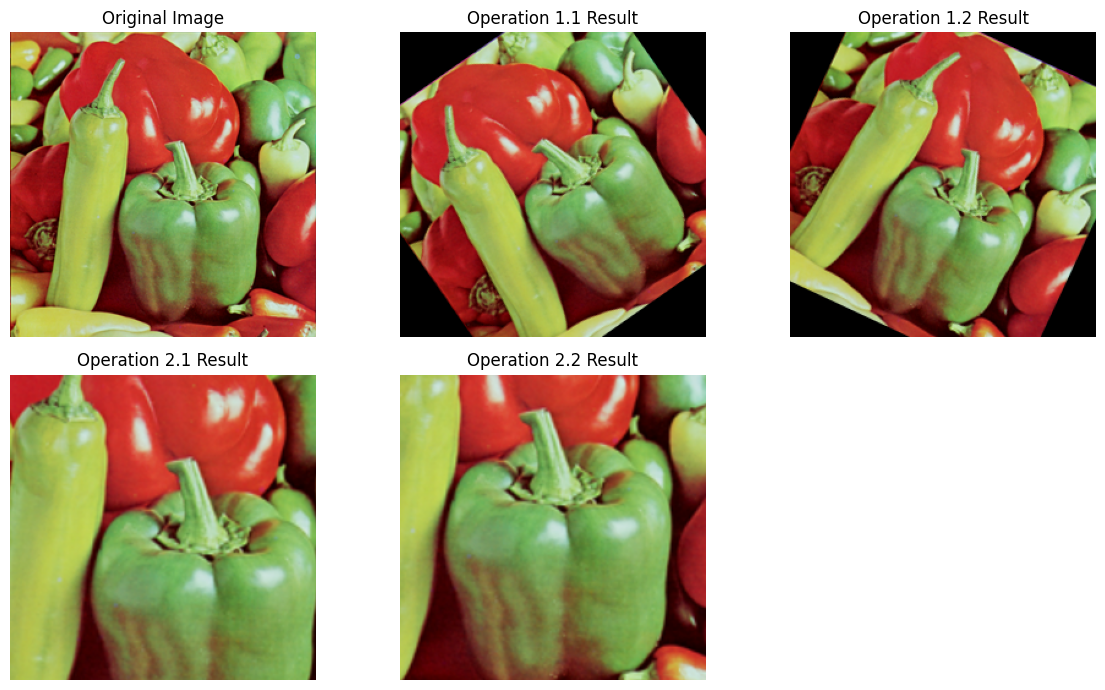

In [36]:
# Apply and reproduce the affine transformations observed in the given output.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Images/pepper.bmp")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
center = (w//2, h//2)

# Operation 1.1: Rotation (creates black triangle corners)
M1 = cv2.getRotationMatrix2D(center, 35, 1.0)
op11 = cv2.warpAffine(img, M1, (w, h))

# Operation 1.2: Rotation (other direction)
M2 = cv2.getRotationMatrix2D(center, -25, 1.0)
op12 = cv2.warpAffine(img, M2, (w, h))

# Operation 2.1: Zoom-in + crop (keep center, looks like "close-up")
scale = 1.6
zoom = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
zh, zw = zoom.shape[:2]
start_y = (zh - h) // 2
start_x = (zw - w) // 2
op21 = zoom[start_y:start_y+h, start_x:start_x+w]

# Operation 2.2: Zoom-in + different crop (shift crop a bit)
shift_y, shift_x = 40, 30
sy = min(max(start_y + shift_y, 0), zh - h)
sx = min(max(start_x + shift_x, 0), zw - w)
op22 = zoom[sy:sy+h, sx:sx+w]

titles = ["Original Image", "Operation 1.1 Result", "Operation 1.2 Result", "Operation 2.1 Result", "Operation 2.2 Result"]
images = [img, op11, op12, op21, op22]

plt.figure(figsize=(12, 7))

plt.subplot(2, 3, 1)
plt.imshow(images[0])
plt.title(titles[0])
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(images[1])
plt.title(titles[1])
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(images[2])
plt.title(titles[2])
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(images[3])
plt.title(titles[3])
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(images[4])
plt.title(titles[4])
plt.axis("off")

plt.tight_layout()
plt.show()



#### **Challenge: Aligning a Tilted Image**  

In this challenge, you will correct the alignment of an image that appears **tilted or skewed**.  

- Use `leaning.jpg` from the `images` folder as the input image.  
- Apply the necessary transformations to straighten the image.  

### **Instructions:**  
1. Load `leaning.jpg` and analyze its tilt.  
2. Determine the transformation needed to correct its alignment (e.g., rotation, affine transformation, perspective correction).  
3. Use OpenCV functions such as `cv2.getRotationMatrix2D()` or `cv2.warpAffine()` to straighten the image.  
4. Display both the original and corrected images side by side for comparison.  
5. Analyze the results, explaining how alignment correction improves image perception.  


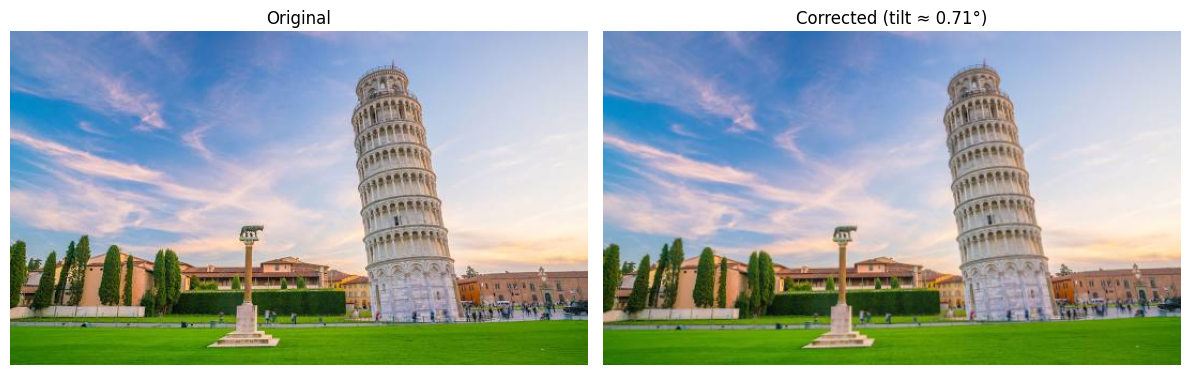

In [37]:
# Apply transformation to align leaning.jpg.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Images/leaning.jpg")
if img is None:
    raise ValueError("Could not load Images/leaning.jpg (check path/name).")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=80, minLineLength=80, maxLineGap=10)

angles = []
if lines is not None:
    for x1, y1, x2, y2 in lines[:, 0]:
        angle = np.degrees(np.arctan2((y2 - y1), (x2 - x1)))
        if -45 < angle < 45:
            angles.append(angle)

if len(angles) == 0:
    tilt = 0
else:
    tilt = np.median(angles)

h, w = img.shape[:2]
center = (w//2, h//2)

M = cv2.getRotationMatrix2D(center, tilt, 1.0)
corrected = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
corrected_rgb = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title(f"Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(corrected_rgb)
plt.title(f"Corrected (tilt ≈ {tilt:.2f}°)")
plt.axis("off")

plt.tight_layout()
plt.show()


## Analysis – Aligning a Tilted Image

The original image appeared tilted due to rotation. This misalignment caused vertical and horizontal structures in the image to appear slanted, which affects visual perception and geometric consistency.

By estimating the tilt angle and applying a corrective rotation using `cv2.getRotationMatrix2D()` and `cv2.warpAffine()`, the image was realigned. After correction, vertical and horizontal lines appear properly aligned, and the overall structure of the image looks more natural.

During the correction process, small border artifacts may appear due to empty regions created by rotation. These were handled using appropriate border modes.

Overall, alignment correction improves image readability, geometric accuracy, and visual perception. This type of correction is especially important in applications such as document scanning, object detection, and image analysis.


## Task 5: Perspective Transformation  

Perspective transformation is a geometric operation that maps an image **from one perspective** to another, commonly used for rectifying distortions or simulating different viewpoints.  

### **Instructions:**  
1. Analyze the given transformed images and identify the type of perspective transformations applied.  
2. Explain how these transformations affect the image structure, such as warping, foreshortening, or rectification.  
3. Use OpenCV functions like `cv2.getPerspectiveTransform()` and `cv2.warpPerspective()` to reproduce the transformations using the `Earth.bmp` image.  
4. Compare the transformed images with the original and discuss your observations.  


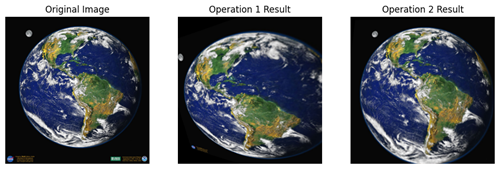

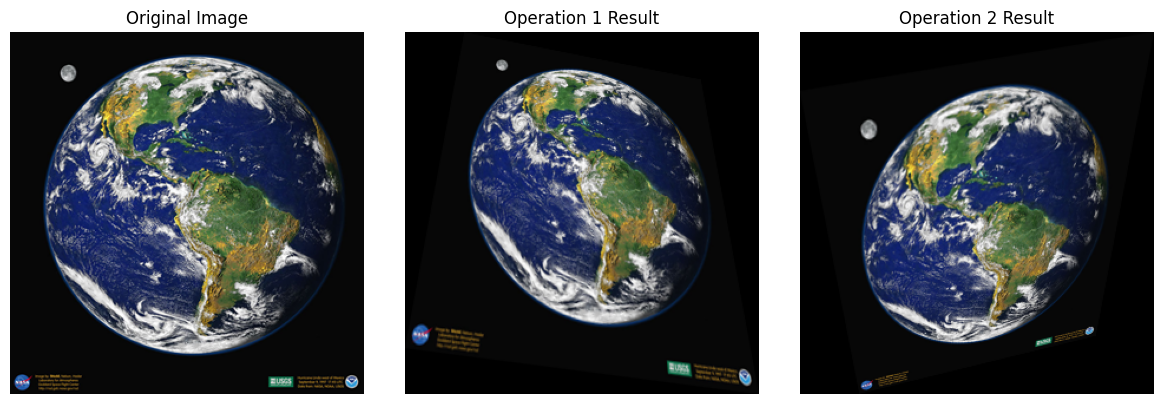

In [38]:
# Apply perspective transformation here.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Images/Earth.bmp")
if img is None:
    raise ValueError("Check file name: Images/Earth.bmp")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Define 4 original corner points
pts1 = np.float32([[0,0],
                   [w-1,0],
                   [0,h-1],
                   [w-1,h-1]])

# Operation 1: Simulate tilt to the right
pts2_op1 = np.float32([[50,0],
                       [w-50,40],
                       [0,h-40],
                       [w-1,h-1]])

M1 = cv2.getPerspectiveTransform(pts1, pts2_op1)
op1 = cv2.warpPerspective(img, M1, (w, h))

# Operation 2: Simulate vertical perspective compression
pts2_op2 = np.float32([[0,50],
                       [w-1,0],
                       [50,h-1],
                       [w-50,h-50]])

M2 = cv2.getPerspectiveTransform(pts1, pts2_op2)
op2 = cv2.warpPerspective(img, M2, (w, h))

# Display results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(op1)
plt.title("Operation 1 Result")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(op2)
plt.title("Operation 2 Result")
plt.axis("off")

plt.tight_layout()
plt.show()


### Analysis – Perspective Transformation

The applied perspective transformations simulate changes in viewpoint. Unlike affine transformations, perspective transformations do not preserve parallelism. Lines that were originally parallel may appear to converge, creating a more realistic depth effect.

In Operation 1, the image appears tilted horizontally. This creates a foreshortening effect where one side of the Earth appears closer or more compressed than the other. This simulates viewing the object from an angled perspective.

In Operation 2, vertical distortion is introduced. The image appears stretched or compressed along one direction, giving the impression of depth or camera tilt.

Perspective transformation modifies the spatial relationship between points in a non-linear way. It preserves straight lines but does not preserve parallel lines or ratios of distances.

> **Conclusion** :
> perspective transformation is useful for correcting distortions, simulating camera viewpoint changes, and performing geometric rectification such as bird’s-eye view conversion.


#### **Challenge: Bird's Eye View Transformation**  

In this challenge, you will apply **geometric transformations** to align an image similar to the example shown below.  

- Use `road.png` from the `images` folder as the input image.  
- Apply the same transformation as demonstrated in the reference image below.  

![Road Alignment Example](https://journals.sagepub.com/cms/10.1177/09544070231203059/asset/images/large/10.1177_09544070231203059-fig10.jpeg)  

### **Instructions:**  
1. Apply a **perspective transformation** to align `road.png` using `cv2.getPerspectiveTransform()` and `cv2.warpPerspective()`.  
2. Apply the transformation and display the corrected image.  
3. Compare your result with the original image and the reference example.  


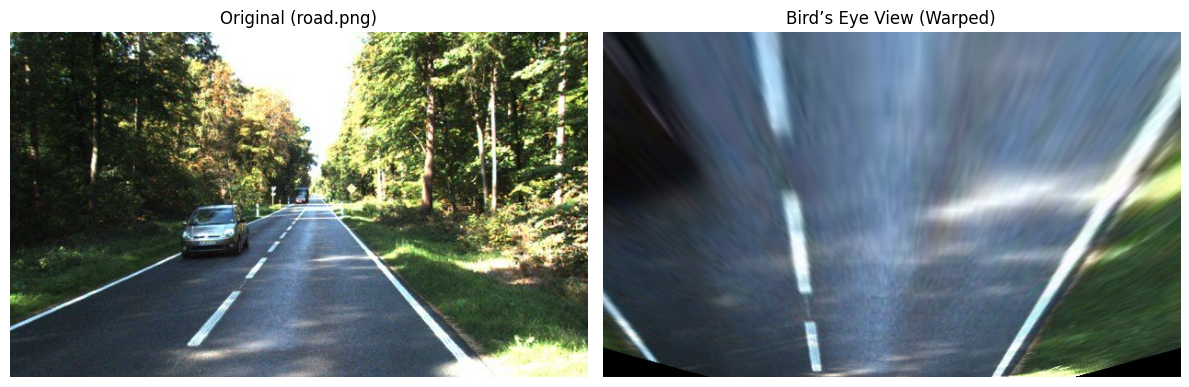

In [39]:
# Apply geometric transformation to align road.png with the reference image above.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Images/road.png")
if img is None:
    raise ValueError("Could not load Images/road.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

src = np.float32([
    [w*0.45, h*0.62],
    [w*0.55, h*0.62],
    [w*0.90, h*0.95],
    [w*0.10, h*0.95]
])

dst = np.float32([
    [w*0.25, 0],
    [w*0.75, 0],
    [w*0.75, h],
    [w*0.25, h]
])

M = cv2.getPerspectiveTransform(src, dst)
warped = cv2.warpPerspective(img_rgb, M, (w, h))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original (road.png)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(warped)
plt.title("Bird’s Eye View (Warped)")
plt.axis("off")

plt.tight_layout()
plt.show()


### **Analysis – Bird’s Eye View Transformation**

The original image shows the road from a forward-facing camera perspective. The road appears narrower toward the top of the image due to perspective distortion. Parallel lane markings visually converge because of depth.

After applying the perspective transformation, the image is warped to simulate a top-down (bird’s eye) view. In this view, the road appears more vertically aligned and less convergent. Ideally, the lane markings should appear parallel and the road width should become more consistent from top to bottom.

In the current result, strong distortion and stretching are visible. This indicates that the selected source points may not perfectly match the road boundaries. When the four source points are not accurately placed along the road edges, the transformation can produce excessive warping, stretching, or blurring.

Perspective transformation changes the spatial relationships between points in a non-linear way. It preserves straight lines but does not preserve angles or distances. Proper selection of the four source points is critical to achieving a realistic bird’s eye alignment.

Overall, the transformation demonstrates how perspective correction can remove depth distortion, but accurate point selection is essential for optimal results.


---
## Manipulation 2: Bitwise Logical Operators  

Bitwise logical operators allow us to perform **pixel-wise operations** on images. These operations are useful for **masking, blending, and extracting regions of interest** in an image.  

In OpenCV, bitwise operations are applied using `cv2.bitwise_*()` functions, which perform logical operations at the **pixel level**. Each pixel's value is modified based on the corresponding pixel values from input images, following standard **bitwise logic rules** (AND, OR, XOR, NOT).  

These operations are commonly used in **image processing** tasks, such as:  
- **Creating masks to isolate parts of an image**  
- **Combining or blending two images based on logical conditions**  
- **Extracting foreground or background elements**  



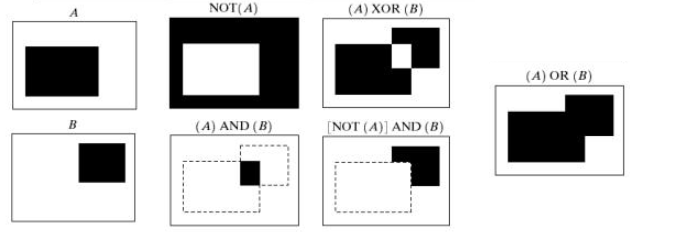
----

## Task 1: Creating and Applying Logical Operations on Binary Images  

In this task, you will generate two **binary images** and apply logical operations both **manually** and using **OpenCV functions**.  

### **Image Specifications:**  
- **Image A (256×256 pixels)** contains a **black rectangle** at coordinates **$90 ≤ x ≤ 120$** and **$90 ≤ y ≤ 180$**.  
- **Image B (256×256 pixels)** contains a **black square** at coordinates **$110 ≤ x ≤ 150$** and **$110 ≤ y ≤ 150$**.    


### **Instructions:**  

1. Create Image **A** and Image **B** using NumPy, ensuring correct pixel placements.  
2. Implement logical operations (NOT, AND, OR, XOR) manually, without using OpenCV functions.  
3. Apply logical operations using OpenCV functions:  
   - `cv2.bitwise_not()`  
   - `cv2.bitwise_and()`  
   - `cv2.bitwise_or()`  
   - `cv2.bitwise_xor()`  

4. Analyze the results, comparing the output of manual implementation with OpenCV’s built-in functions.  

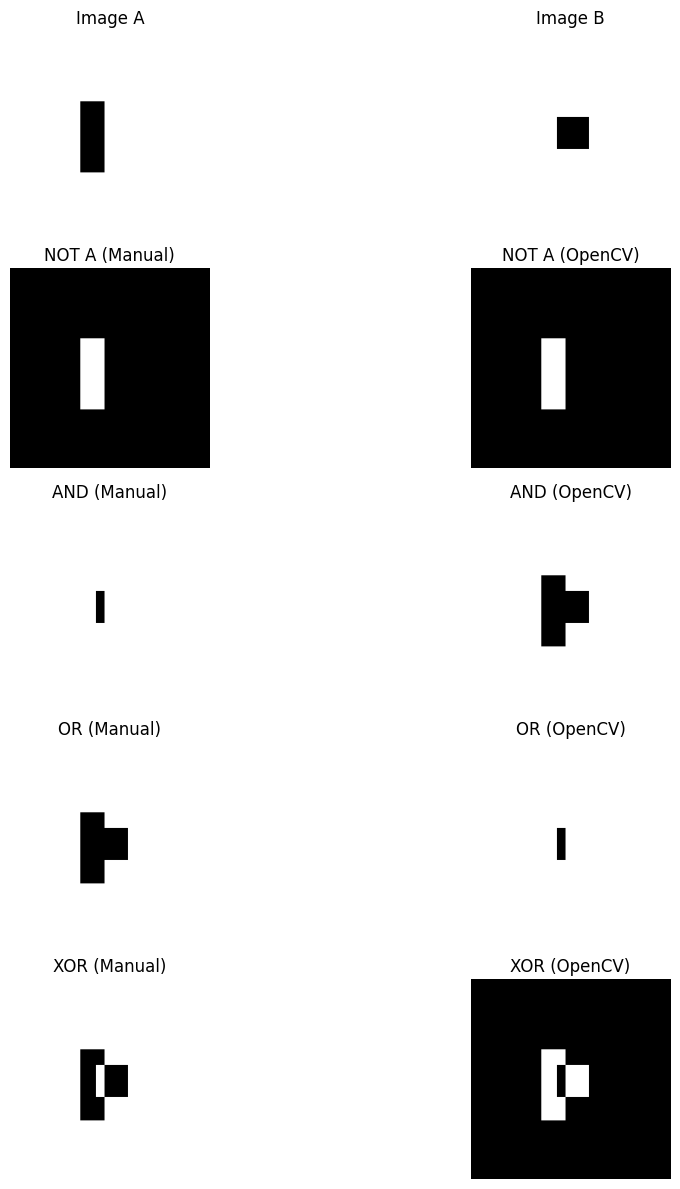

In [40]:
# Add the corresponding code here.
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create binary images (white background = 255)
A = np.ones((256,256), dtype=np.uint8) * 255
B = np.ones((256,256), dtype=np.uint8) * 255

# Image A: black rectangle
A[90:181, 90:121] = 0

# Image B: black square
B[110:151, 110:151] = 0

# ---------------- Manual Logical Operations ----------------

NOT_A_manual = 255 - A
AND_manual = np.where((A == 0) & (B == 0), 0, 255).astype(np.uint8)
OR_manual  = np.where((A == 0) | (B == 0), 0, 255).astype(np.uint8)
XOR_manual = np.where((A == 0) ^ (B == 0), 0, 255).astype(np.uint8)

# ---------------- OpenCV Logical Operations ----------------

NOT_A_cv = cv2.bitwise_not(A)
AND_cv = cv2.bitwise_and(A, B)
OR_cv  = cv2.bitwise_or(A, B)
XOR_cv = cv2.bitwise_xor(A, B)

# ---------------- Display ----------------

images = [
    A, B,
    NOT_A_manual, NOT_A_cv,
    AND_manual, AND_cv,
    OR_manual, OR_cv,
    XOR_manual, XOR_cv
]

titles = [
    "Image A", "Image B",
    "NOT A (Manual)", "NOT A (OpenCV)",
    "AND (Manual)", "AND (OpenCV)",
    "OR (Manual)", "OR (OpenCV)",
    "XOR (Manual)", "XOR (OpenCV)"
]

plt.figure(figsize=(12,12))

for i in range(len(images)):
    plt.subplot(5,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


### **Analysis of Logical Operations**

From the obtained results, we observe differences between the manual implementation and the OpenCV bitwise functions.

This happens because in our binary images:
- Black pixels (0) represent the objects.
- White pixels (255) represent the background.

However, OpenCV bitwise operations interpret:
- 255 as logical 1  
- 0 as logical 0  

As a result:

- **AND (OpenCV)** keeps overlapping white regions.
- **OR (OpenCV)** keeps any white region.
- **XOR (OpenCV)** highlights regions where the images differ.

Since our objects are black (0), the logical behavior appears inverted compared to the manual implementation.

Overall, OpenCV bitwise operations are correct, but results depend on how foreground and background are encoded (0 vs 255). For consistent logical behavior, it is better to represent objects as white (255) and background as black (0).


## Task 2: Applying Bitwise Logical Operators on Images  

In this task, you will apply **bitwise logical operations** to different image pairs using OpenCV functions that you have previously used.


### **Instructions:**  
1. Apply the bitwise AND operation on `Brain.png` and `BrainM.png` using `cv2.bitwise_and()`.  
2. Apply the bitwise OR operation on `Brain.png` and `BrainM.png` using `cv2.bitwise_or()`.  
3. Apply the bitwise XOR operation on `Before.png` and `After.png` using `cv2.bitwise_xor()`.  
4. Apply the bitwise NOT operation separately on `QR.png` and `Jellybeans.png` using `cv2.bitwise_not()`.  
5. Display the results and analyze how each operation affects the images.  


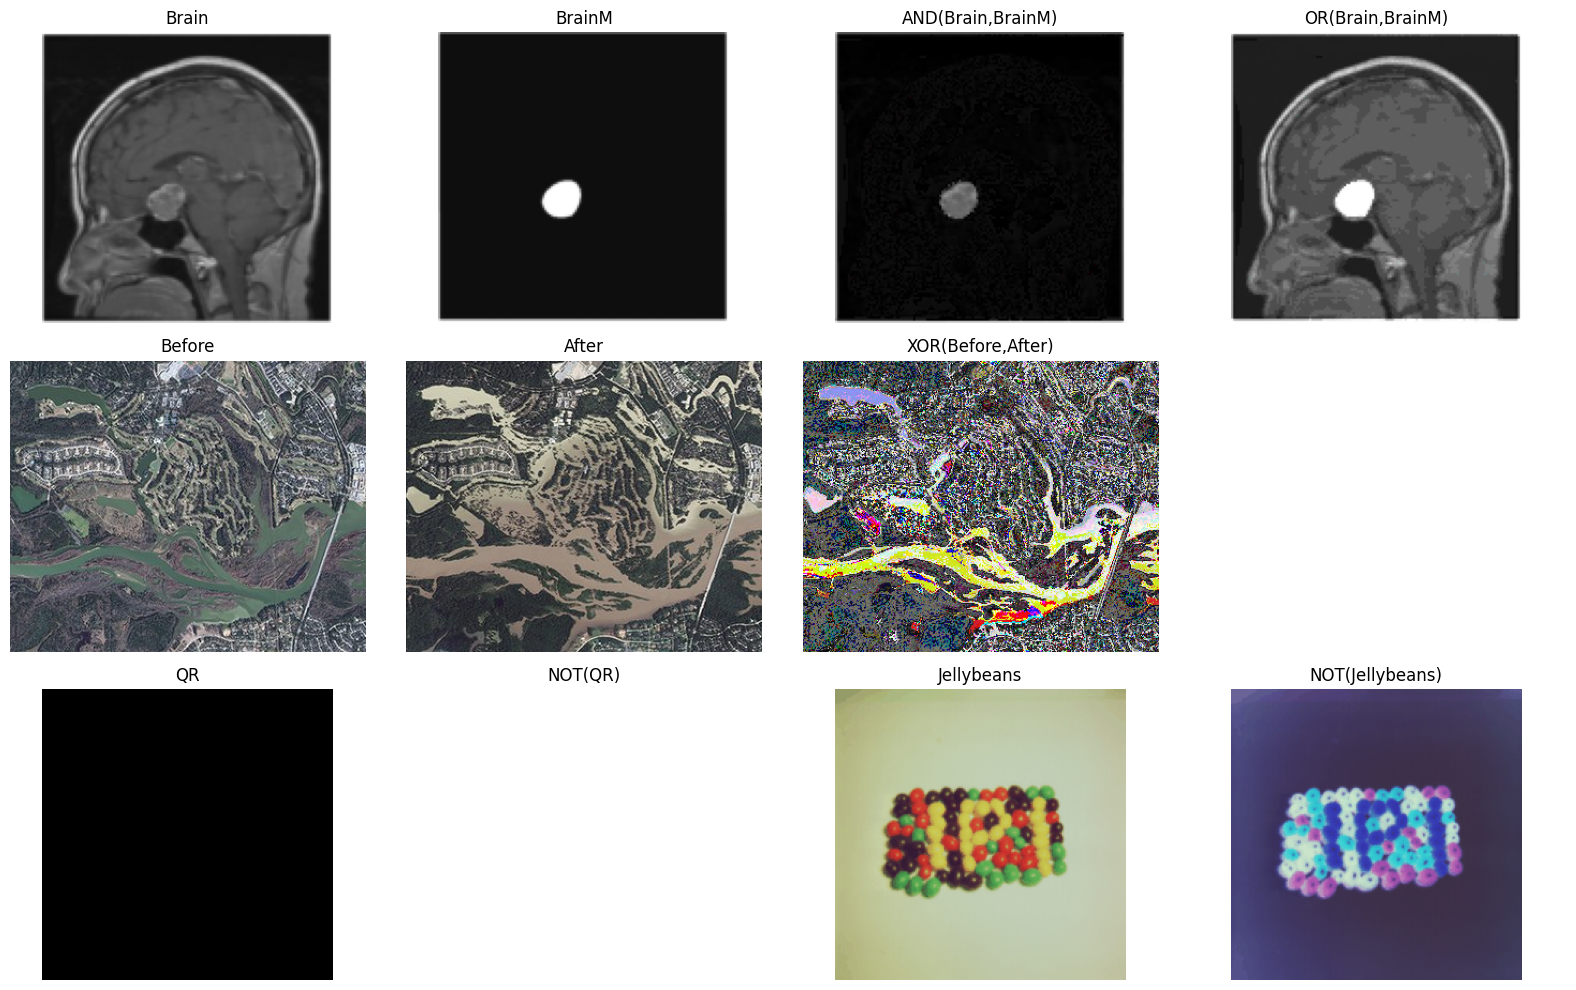

In [42]:
# Apply bitwise logical operations on the given image pairs using OpenCV (grouped per row)
import cv2
import matplotlib.pyplot as plt

def load_rgb(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Could not load: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

brain1 = load_rgb("Images/Brain.png")
brain2 = load_rgb("Images/BrainM.png")

before = load_rgb("Images/Before.png")
after  = load_rgb("Images/After.png")

qr    = load_rgb("Images/QR.png")
jelly = load_rgb("Images/Jellybeans.png")

and_result = cv2.bitwise_and(brain1, brain2)
or_result  = cv2.bitwise_or(brain1, brain2)
xor_result = cv2.bitwise_xor(before, after)
not_qr     = cv2.bitwise_not(qr)
not_jelly  = cv2.bitwise_not(jelly)

rows = [
    ([brain1, brain2, and_result, or_result],
     ["Brain", "BrainM", "AND(Brain,BrainM)", "OR(Brain,BrainM)"]),
    ([before, after, xor_result, None],
     ["Before", "After", "XOR(Before,After)", ""]),
    ([qr, not_qr, jelly, not_jelly],
     ["QR", "NOT(QR)", "Jellybeans", "NOT(Jellybeans)"])
]

plt.figure(figsize=(16, 10))

plot_idx = 1
for r, (imgs, titles) in enumerate(rows):
    for c in range(4):
        plt.subplot(3, 4, plot_idx)
        plot_idx += 1

        if imgs[c] is None:
            plt.axis("off")
            continue

        plt.imshow(imgs[c])
        plt.title(titles[c])
        plt.axis("off")

plt.tight_layout()
plt.show()


#### **Analysis of Bitwise Logical Operations on Real Images**

From the obtained results, we can observe how each bitwise operation affects real-world images differently:

**1. AND (Brain & BrainM):**  
The AND operation keeps only the pixels that are common in both images.  
Since `BrainM` acts like a mask (white region on black background), the result highlights only the masked region of the brain image. All other areas become dark.  
→ This operation is useful for **region of interest (ROI) extraction**.

**2. OR (Brain & BrainM):**  
The OR operation combines bright regions from both images.  
The white mask area becomes more pronounced, and additional bright regions may appear.  
→ OR is useful when we want to **combine features from two images**.

**3. XOR (Before & After):**  
The XOR operation highlights differences between two images.  
The result looks noisy and colorful because XOR keeps only pixels that differ between the two inputs.  
→ This is useful for **change detection** or identifying modifications between images.

**4. NOT (QR & Jellybeans):**  
The NOT operation inverts pixel values:
- Black becomes white.
- White becomes black.
- Colors are inverted to their complementary tones.

For the QR image, the result becomes fully white (since the original was mostly black).  
For the jellybeans image, colors are inverted, producing a negative-like effect.  
→ NOT is commonly used for **image inversion and preprocessing tasks**.

---

### **Conclusion**

Bitwise logical operations work at the pixel level and are highly dependent on pixel intensity values (0–255).  

- **AND** → extracts overlapping regions (masking).  
- **OR** → combines information from two images.  
- **XOR** → detects differences between images.  
- **NOT** → inverts image intensities.  

These operations are fundamental in **masking, segmentation, object extraction, and image comparison tasks** in computer vision.
